In [ ]:
import gdsfactory as gf
from ihp import PDK
from ihp.cells.capacitors import cmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

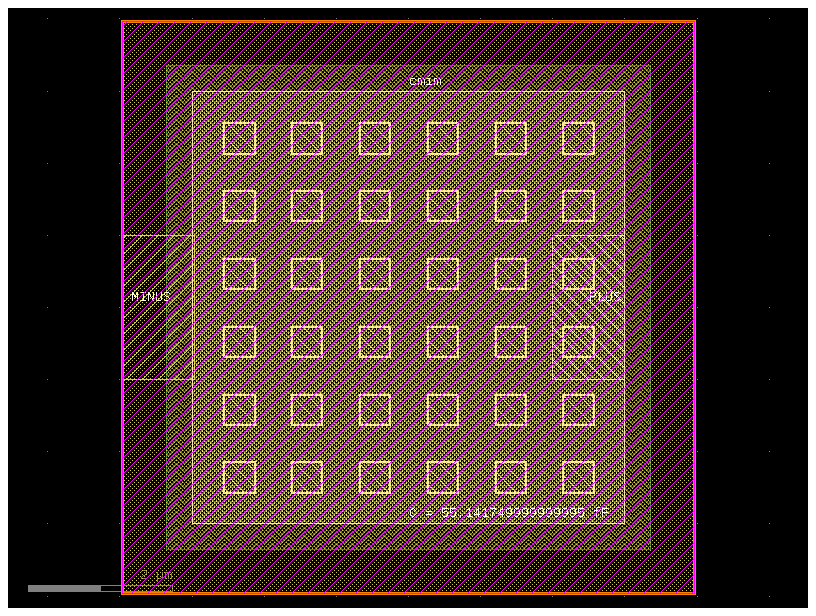

In [ ]:
c = cmim(width=6.0, length=6.0)

cc = c.copy()
cc.flatten()

cc

In [28]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-cmim")
sim.set_geometry(cc)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("PLUS",layer="topmetal1",geometry="inplane",length=2.0,impedance=50.0)
sim.add_port("MINUS",layer="metal5",geometry="inplane",length=2.0,impedance=50.0)

sim.set_driven(fmin=1e9, fmax=20e9, num_points=20)

print(sim.validate_config())

Validation: PASSED


In [30]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 207.9 x 207.9 x 518.3 µm
Nodes:      1,320
Elements:   11,269
Tetrahedra: 7,150
Edge length: 0.01 - 126.85 µm
Quality:    0.478 (min: 0.002)
SICN:       0.518 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (8):
  - metal5_xy [6]
  - metal5_z [7]
  - topmetal1_xy [8]
  - topmetal1_z [9]
  - vmim_xy [10]
  - P1 [11]
  - P2 [12]
  - Absorbing_boundary [13]
----------------------------------------
Mesh:   ../palace-sim-cmim/palace.msh

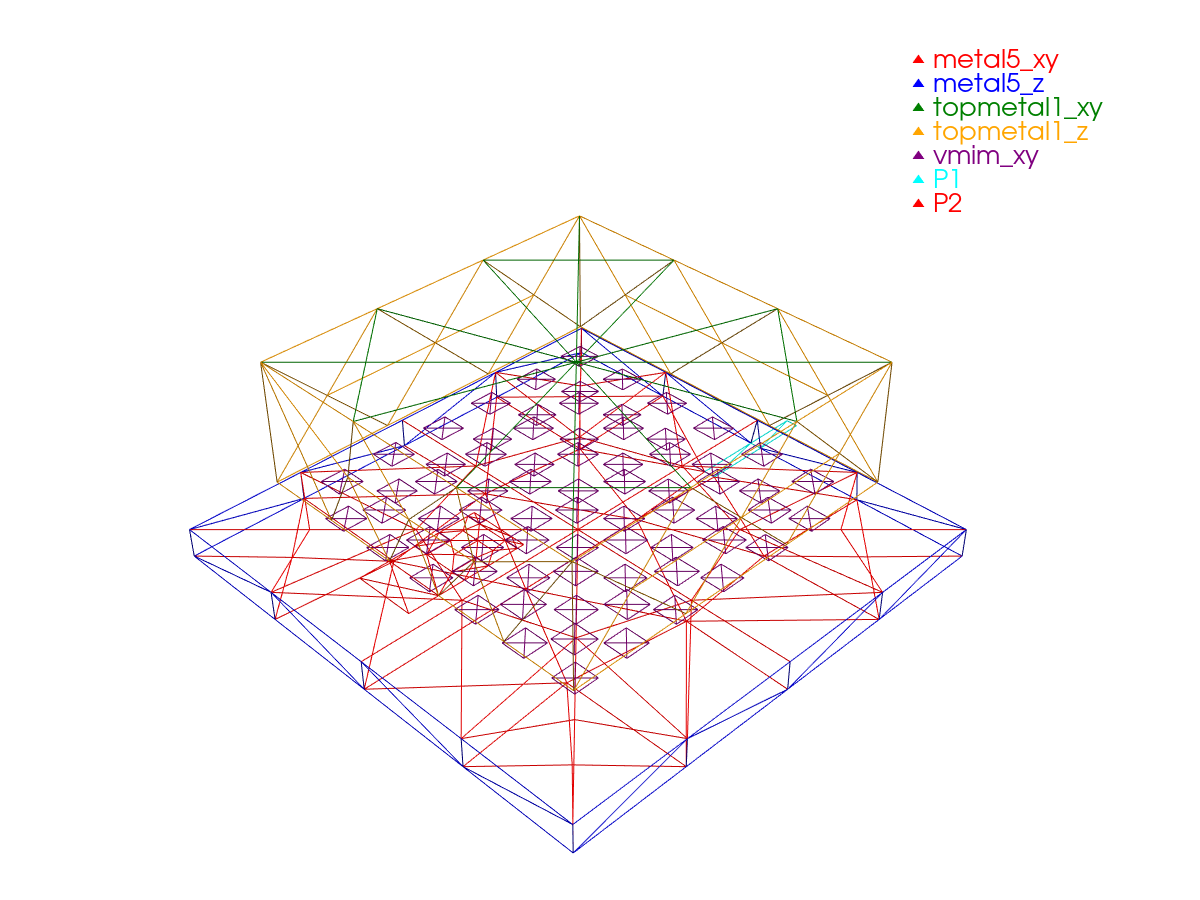

In [33]:
sim.plot_mesh(show_groups=["metal","vmim","P"], interactive=False)